In [1]:
import os
import sys
sys.path.append("../")
sys.path.append("../21cmfast_sim/")


import numpy as np

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
from matplotlib.lines import Line2D


%load_ext autoreload
%autoreload 2
%matplotlib inline

from plot_params import params
from galaxy_survey import *
pylab.rcParams.update(params)
cols_default = plt.rcParams['axes.prop_cycle'].by_key()['color']

## Recompute Correlation Functions
Run the cells in this section to recompute the correlation functions. Note that this takes a long time and requires a bunch of cores. To avoid this, skip this part and run the cells below where the correlation is loaded from file.

In [ ]:

cache_name = f'/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/v4_lightcones/'
lc_name = "LightCone_z5.5_HIIDIM=200_BOXLEN=300.0_r3843290498042390.h5"
lightconer_name = "lightconer_seed3843290498042390.pkl"
point_source_dir = "/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/pointsource_sky_maps/"
roman = Survey("Roman", "Lya", 
        cache=cache_name, 
        lc_name=lc_name, 
        lightconer_name=lightconer_name, 
        nside=2048, 
        # foregrounds_path="/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/pyilc_no_pt_srcs/all_foregrounds.npy",
        foregrounds_path="/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/pyilc_foregrounds_no_pt_srcs_low_freq/",
        clean_map_loc="/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/pyilc_foregrounds_no_pt_srcs_low_freq/clean_needlet_ILC_map_subaru_20deg_LOFARthermal_mK.fits",
        use_pixel_ilc=False,
        )

In [ ]:
mA = 3e-14
roman.cross_correlate(mA)
np.save(f"data/roman_mA{mA:.3e}_obs_cross_xi.npy", [roman.obs_cross_rnom, roman.obs_cross_xi])
np.save(f"data/roman_mA{mA:.3e}_obs_cross_cov.npy", roman.obs_cross_cov)

np.save(f"data/roman_mA{mA:.3e}_pred_cross_xi.npy", [roman.pred_cross_rnom, roman.pred_cross_xi])
np.save(f"data/roman_mA{mA:.3e}_pred_cross_cov.npy", roman.pred_cross_cov)

In [ ]:
roman.auto_correlate(mA)
np.save(f"data/roman_mA{mA:.3e}_obs_auto_xi.npy", [roman.obs_auto_rnom, roman.obs_auto_xi])
np.save(f"data/roman_mA{mA:.3e}_obs_auto_cov.npy", roman.obs_auto_cov)

np.save(f"data/roman_mA{mA:.3e}_pred_auto_xi.npy", [roman.pred_auto_rnom, roman.pred_auto_xi])
np.save(f"data/roman_mA{mA:.3e}_pred_auto_cov.npy", roman.pred_auto_cov)

## Plot Pre-computed Correlation Functions

We first load the observed auto-correlation function of ILC cleaned map and its covariance.
Then, we load the predicted dark photon auto-correlation function computed from our map of $P^{\gamma \to A'}$. 

Then, we load the observed cross-correlation function between the ILC map and the simulated *Roman* galaxy catalog. Finally, we load the predicted cross-correlation between the simulated catalog and dark photon signal. 

Note that the angles are the same for each, but we load each individually because of a quirk in how these are all saved.


In [2]:
mA = 3e-14
obs_cross_rnom, obs_cross_xi = np.load(f"data/roman_mA{mA:.3e}_obs_cross_xi.npy")
obs_cross_cov = np.load(f"data/roman_mA{mA:.3e}_obs_cross_cov.npy")

pred_cross_rnom, pred_cross_xi = np.load(f"data/roman_mA{mA:.3e}_pred_cross_xi.npy")
pred_cross_cov = np.load(f"data/roman_mA{mA:.3e}_pred_cross_cov.npy")

obs_auto_rnom, obs_auto_xi = np.load(f"data/roman_mA{mA:.3e}_obs_auto_xi.npy",)
obs_auto_cov = np.load(f"data/roman_mA{mA:.3e}_obs_auto_cov.npy")

pred_auto_rnom, pred_auto_xi = np.load(f"data/roman_mA{mA:.3e}_pred_auto_xi.npy",)
pred_auto_cov = np.load(f"data/roman_mA{mA:.3e}_pred_auto_cov.npy")

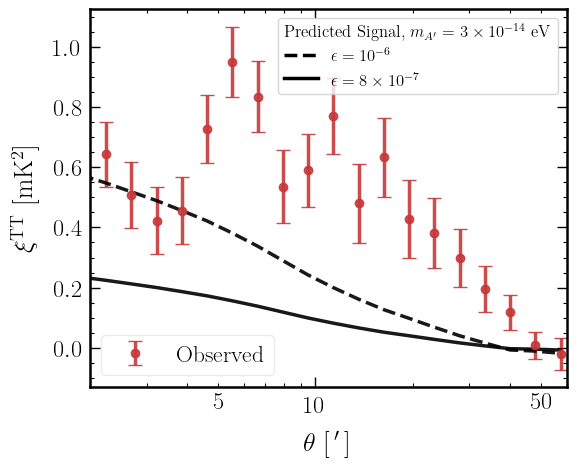

In [10]:
from matplotlib.ticker import MultipleLocator, FixedLocator

# plot auto-correlations
Tgamma0 = 2.73e3
epsilon_high = 1e-6
epsilon_low = 8e-7
new_prefac = 2* np.pi * 410e6 * 6.58212e-16 # convert MHz to eV and normalizes to radio frequ

angle_arcmin = obs_auto_rnom * 180/np.pi * 60
plt.errorbar(angle_arcmin, obs_auto_xi/new_prefac**2, yerr=np.sqrt(np.diag(obs_auto_cov))/new_prefac**2, marker="o", linestyle=" ", label="Observed")
plt.plot(angle_arcmin, epsilon_high**4 * pred_auto_xi/new_prefac**2, "--", color="k")
plt.plot(angle_arcmin, epsilon_low**4 * pred_auto_xi/new_prefac**2, "-", color="k")

plt.xlabel(r"$\theta$ [$\, ^\prime\, $]")
plt.ylabel(r"$\xi^{\rm TT}$ [mK$^2$]")
plt.xscale("log")
# Set major and minor ticks as before, but keep all original ticks
ax = plt.gca()
current_ticks = ax.get_xticks(minor=True)

theory_line = Line2D([0,1],[0,1],linestyle='--', color='k')
# Add labels at x=5 and x=50 while keeping existing minor ticks
new_minor_ticks = np.unique(np.append(current_ticks, [5.0, 50.0]))
ax.set_xticks(new_minor_ticks, minor=True)
minor_labels = [("5" if np.isclose(t, 5.0) else "50" if np.isclose(t, 50.0) else "") for t in new_minor_ticks]
ax.set_xticklabels(minor_labels, minor=True)
theory_line2 = Line2D([0,1],[0,1],linestyle='-', color='k')


legend2 = plt.legend([theory_line, theory_line2], [r"$\epsilon=10^{-6}$", r"$\epsilon=8\times 10^{-7}$"], 
                    loc="upper right", 
                    frameon=True, fontsize=12, title=r"Predicted Signal, $m_{A'}=3\times 10^{-14}$ eV", title_fontsize=12, framealpha=0.8)
# legend2.set_title(r"Predicted Signal, $m_{A'}=5.6\times 10^{-13}$ eV")
plt.gca().add_artist(legend2)
legend2._legend_box.align = 'left'
plt.xlim(2, 60)
    
# legend1 = plt.legend(fontsize=12, frameon=True, 
#                      loc="lower left", 
#                      framealpha=0.75) # loc='center left', bbox_to_anchor=(1, 0.5))

plt.legend(loc="lower left", frameon=True)
plt.savefig(f"plots/roman_mA{mA:.3e}_auto_corr.pdf", bbox_inches="tight")

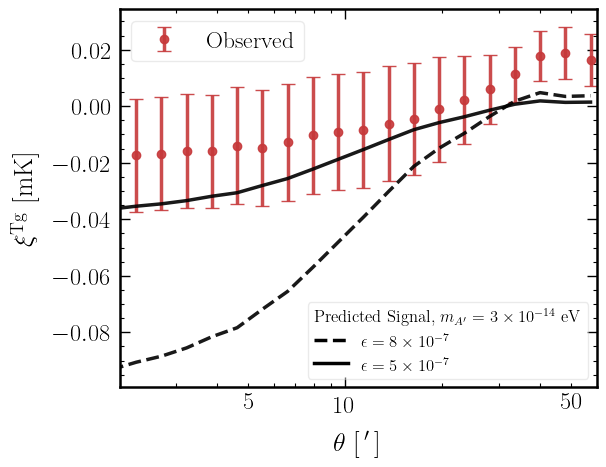

In [11]:
# plot cross-correlations
epsilon_high = 8e-7
epsilon_low = 5e-7
plt.errorbar(angle_arcmin, obs_cross_xi/new_prefac, yerr=np.sqrt(np.diag(obs_cross_cov))/new_prefac, marker="o", linestyle=" ", label="Observed")
plt.plot(angle_arcmin, epsilon_high**2 * pred_cross_xi/new_prefac, "--", color="k")
plt.plot(angle_arcmin, epsilon_low**2 * pred_cross_xi/new_prefac, "-", color="k")

plt.xlabel(r"$\theta$ [$\, ^\prime\, $]")
plt.ylabel(r"$\xi^{\rm Tg}$ [mK]")
plt.xscale("log")

ax = plt.gca()
current_ticks = ax.get_xticks(minor=True)

theory_line = Line2D([0,1],[0,1],linestyle='--', color='k')
# Add labels at x=5 and x=50 while keeping existing minor ticks
new_minor_ticks = np.unique(np.append(current_ticks, [5.0, 50.0]))
ax.set_xticks(new_minor_ticks, minor=True)
minor_labels = [("5" if np.isclose(t, 5) else "50" if np.isclose(t, 50.0) else "") for t in new_minor_ticks]
ax.set_xticklabels(minor_labels, minor=True)
theory_line2 = Line2D([0,1],[0,1],linestyle='-', color='k')


legend2 = plt.legend([theory_line, theory_line2], [r"$\epsilon=8\times 10^{-7}$", r"$\epsilon=5\times 10^{-7}$"], 
                    loc="lower right", frameon=True, fontsize=12, 
                    title=r"Predicted Signal, $m_{A'}=3\times 10^{-14}$ eV", title_fontsize=12)
# legend2.set_title(r"Predicted Signal, $m_{A'}=5.6\times 10^{-13}$ eV")
plt.gca().add_artist(legend2)

legend2._legend_box.align = 'left'
# legend1 = plt.legend(fontsize=12, frameon=True, loc="upper right", framealpha=0.75) # loc='center left', bbox_to_anchor=(1, 0.5))
plt.xlim(2, 60)

plt.legend(loc="upper left", frameon=True)
plt.savefig(f"plots/roman_mA{mA:.3e}_cross_corr.pdf", bbox_inches="tight")
